<a href="https://colab.research.google.com/github/aadityane93/Toxic_Comments_Sentiment_Analysis/blob/reportAj/5_Binary_Label_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Label Transfer Learning


In [10]:
# !pip install datasets transformers scikit-learn # For Colab
!git clone https://github.com/aadityane93/Toxic_Comments_Sentiment_Analysis.git
%cd Toxic_Comments_Sentiment_Analysis
!pip uninstall -y torchvision torchaudio


Cloning into 'Toxic_Comments_Sentiment_Analysis'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 140 (delta 18), reused 15 (delta 4), pack-reused 84 (from 1)
Receiving objects: 100% (140/140), 53.64 MiB | 12.24 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/Toxic_Comments_Sentiment_Analysis/Toxic_Comments_Sentiment_Analysis


In [11]:
# This quick check tells us whether PyTorch can see a GPU.
# Training DistilBERT on CPU can still work, but it will be much slower.
# If this prints True and shows a GPU name, the training cell should finish much faster.
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


GPU available: True
GPU name: Tesla T4


In [12]:
# Basic libraries for tables, numbers, and model training.
# pandas is used for CSV files, numpy is used for metric calculations,
# torch is used by the model, and inspect lets us handle small version
# differences in Hugging Face TrainingArguments.
import pandas as pd
import numpy as np
import torch
import inspect

# Hugging Face tools.
# Dataset converts pandas tables into the format expected by Trainer.
# AutoTokenizer turns comments into token IDs.
# AutoModelForSequenceClassification loads DistilBERT with a classification head.
# TrainingArguments and Trainer handle the training loop for us.
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Metrics for binary classification.
# These are the same main metrics used in the multi-label notebook, with accuracy
# and a confusion matrix added because the task is now one clean/unclean decision.
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


## Load Data And Create Binary Label


In [13]:
# Load the same three CSV files used in the multi-label transfer-learning notebook.
# train.csv has comments and the six original toxicity labels.
# test.csv has comments for the test set.
# test_labels.csv has the real labels for the test comments, but some rows contain -1
# because Kaggle did not score those rows. We remove those -1 rows later before testing.
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
test_labels = pd.read_csv("test_labels.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test labels shape:", test_labels.shape)

# These are the original six labels from the dataset.
# The binary notebook still starts from these columns, but it combines them into one target.
# If any of these labels is 1, the comment is treated as unclean.
# If all six labels are 0, the comment is treated as clean.
target_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# Count how many toxicity labels each training comment has.
# A clean comment has label_count = 0.
# An unclean comment has label_count >= 1.
train_df["label_count"] = train_df[target_cols].sum(axis=1)
train_df["unclean"] = (train_df["label_count"] > 0).astype(int)
train_df["clean"] = 1 - train_df["unclean"]

print("Clean comments:", train_df["clean"].sum())
print("Unclean comments:", train_df["unclean"].sum())
print("Unclean percent:", round(train_df["unclean"].mean() * 100, 2))

train_df.head()


Train shape: (159571, 8)
Test shape: (153164, 2)
Test labels shape: (153164, 7)
Clean comments: 143346
Unclean comments: 16225
Unclean percent: 10.17


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,label_count,unclean,clean
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0,0,1
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0,0,1
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0,0,1
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0,0,1
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0,0,1


## Split Training And Validation Data


In [14]:
# Split the original training data into training and validation parts.
# The original multi-label notebook used a plain random split.
# Here we can stratify because the target is one binary column.
# Stratify keeps the clean/unclean ratio almost the same in both splits,
# which is helpful because only about 10% of the comments are unclean.
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["unclean"]
)

# Reset the index so the rows are numbered from 0 again after splitting.
# This is not required for the model, but it keeps the tables cleaner when we inspect them.
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

print("Training data:", train_data.shape)
print("Validation data:", val_data.shape)
print("Training unclean percent:", round(train_data["unclean"].mean() * 100, 2))
print("Validation unclean percent:", round(val_data["unclean"].mean() * 100, 2))


Training data: (127656, 11)
Validation data: (31915, 11)
Training unclean percent: 10.17
Validation unclean percent: 10.17


## Convert Pandas DataFrames To Hugging Face Datasets


In [15]:
# Hugging Face Trainer works best with a Dataset object instead of a pandas DataFrame.
# We keep all columns for now because the preprocessing function still needs comment_text
# and the new binary label column called unclean.
train_dataset = Dataset.from_pandas(train_data)
val_dataset = Dataset.from_pandas(val_data)

print(train_dataset.column_names)


['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'label_count', 'unclean', 'clean']


## Load DistilBERT Tokenizer


In [16]:
# Use the same pretrained model as the multi-label transfer-learning notebook.
# This keeps the comparison fair: the main change is the target, not the language model.
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


## Tokenize Text And Prepare Binary Labels


In [17]:
def preprocess_data(batch):
    """
    Tokenize comments and create the binary label used by the model.

    The tokenizer changes each comment into numbers that DistilBERT understands.
    The label is stored as a one-item list, for example [0.0] or [1.0].
    That shape matters because the model will output one logit for each comment.
    One logit means one raw score for the question: is this comment unclean?
    """

    # Turn comment text into token IDs and attention masks.
    # truncation=True cuts very long comments so they fit the model input size.
    # padding="max_length" makes every row the same length, which allows batching.
    # max_length=128 is kept from the multi-label notebook so the binary version changes
    # as little as possible from the original transfer-learning setup.
    encoding = tokenizer(
        batch["comment_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # Build labels for binary classification.
    # The model expects floats because we are using BCEWithLogitsLoss internally.
    # 0.0 means clean and 1.0 means unclean.
    labels = []
    for value in batch["unclean"]:
        labels.append([float(value)])

    # Trainer looks for a column named labels.
    # When Trainer passes a batch to the model, these labels are compared with the logits
    # to calculate the training loss.
    encoding["labels"] = labels

    return encoding


## Apply Preprocessing


In [18]:
# Apply the same preprocessing function to training and validation data.
# remove_columns deletes the original text and label columns after they are converted.
# This leaves only the tensors the model needs, such as input_ids, attention_mask, and labels.
train_dataset = train_dataset.map(
    preprocess_data,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_dataset = val_dataset.map(
    preprocess_data,
    batched=True,
    remove_columns=val_dataset.column_names
)


Map:   0%|          | 0/127656 [00:00<?, ? examples/s]

Map:   0%|          | 0/31915 [00:00<?, ? examples/s]

In [19]:
# After preprocessing, the dataset should contain token columns and labels.
# The exact token columns can vary a little by tokenizer, so we print them to confirm.
print(train_dataset.column_names)
print(val_dataset.column_names)


['input_ids', 'token_type_ids', 'attention_mask', 'labels']
['input_ids', 'token_type_ids', 'attention_mask', 'labels']


## Set Dataset Format For PyTorch


In [20]:
# Convert the dataset columns into PyTorch tensors.
# This is the format the DistilBERT model expects during training and evaluation.
train_dataset.set_format("torch")
val_dataset.set_format("torch")


## Load Pretrained DistilBERT Model


In [21]:
# There is only one output now: unclean.
# The model gives one raw number, called a logit, for each comment.
# A larger logit means the model is more confident the comment is unclean.
id2label = {
    0: "unclean"
}

label2id = {
    "unclean": 0
}

# num_labels=1 makes the classification head return one score instead of six.
# problem_type="multi_label_classification" tells Hugging Face to use BCEWithLogitsLoss.
# This is useful for a one-output binary setup because the loss applies sigmoid internally
# and compares the result with labels shaped like [0.0] or [1.0].
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="multi_label_classification",
    id2label=id2label,
    label2id=label2id
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define Evaluation Metrics


In [22]:
def compute_metrics(eval_pred):
    """
    Calculate binary classification metrics at the default threshold of 0.5.

    Trainer calls this function during validation and testing.
    The model returns logits, so we first apply sigmoid to turn them into probabilities.
    Then we use threshold 0.5 to make clean/unclean predictions.
    Later in the notebook we search for a better threshold using validation F1.
    """

    logits, labels = eval_pred

    # Flatten both arrays because this binary model has one output per comment.
    # After flattening, probabilities, labels, and predictions are simple one-dimensional arrays.
    logits = logits.reshape(-1)
    labels = labels.reshape(-1).astype(int)

    # Sigmoid converts any raw logit into a probability between 0 and 1.
    # Example: 0.92 means the model thinks the comment is very likely unclean.
    probabilities = 1 / (1 + np.exp(-logits))

    # Use the normal 0.5 threshold during Trainer evaluation.
    # If probability is 0.5 or higher, predict unclean.
    # Otherwise, predict clean.
    predictions = (probabilities >= 0.5).astype(int)

    # ROC-AUC can fail if a split somehow contains only one class.
    # That should not happen here because we stratified the split, but the try/except
    # makes the function safer and easier to reuse.
    try:
        roc_auc = roc_auc_score(labels, probabilities)
    except ValueError:
        roc_auc = np.nan

    # The confusion matrix shows the actual mistakes, not just one score.
    # labels=[0, 1] fixes the row/column order as clean first, unclean second.
    cm = confusion_matrix(labels, predictions, labels=[0, 1])

    return {
        "roc_auc": roc_auc,
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "clean_correct": cm[0, 0],
        "clean_called_unclean": cm[0, 1],
        "unclean_called_clean": cm[1, 0],
        "unclean_correct": cm[1, 1]
    }


## Define Training Settings


In [28]:
# These settings are almost the same as the multi-label transfer-learning notebook.
# The output folder is changed so the binary model does not overwrite the multi-label model.
# The best model is selected by ROC-AUC because ROC-AUC checks how well the model ranks
# unclean comments above clean comments before we choose a final threshold.
args_dict = {
    "output_dir": "./distilbert-toxic-binary-model",
    "save_strategy": "epoch",

    # Record training loss once per epoch.
    # This is needed so we can draw a loss graph after training.
    "logging_strategy": "epoch",
    "logging_steps": 1,

    "num_train_epochs": 2,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "load_best_model_at_end": True,
    "metric_for_best_model": "roc_auc",
    "greater_is_better": True,
    "report_to": "none",
    "fp16": torch.cuda.is_available()
}

# Hugging Face changed the argument name in different versions.
# Some versions expect eval_strategy and older versions expect evaluation_strategy.
# This check keeps the notebook from breaking just because the installed Transformers
# version uses one name instead of the other.
training_args_params = inspect.signature(TrainingArguments.__init__).parameters

if "eval_strategy" in training_args_params:
    args_dict["eval_strategy"] = "epoch"
else:
    args_dict["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**args_dict)


## Create Trainer


In [29]:
# Trainer connects the model, training settings, datasets, and metric function.
# The actual training still happens in the next cell, but this cell prepares everything.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [30]:


# Start training.
# Trainer will evaluate after each epoch and keep the checkpoint with the best validation ROC-AUC.
trainer.train()

Epoch,Training Loss,Validation Loss,Roc Auc,Accuracy,Precision,Recall,F1,Clean Correct,Clean Called Unclean,Unclean Called Clean,Unclean Correct
1,0.054862,0.159507,0.979844,0.966881,0.861295,0.803698,0.831500,28250,420,637,2608
2,0.040600,0.183589,0.976753,0.965095,0.885632,0.754083,0.814581,28354,316,798,2447
3,0.029232,0.211071,0.978462,0.961711,0.798995,0.832974,0.815631,27990,680,542,2703
4,0.015913,0.238024,0.975764,0.963747,0.842520,0.791371,0.816145,28190,480,677,2568
5,0.011118,0.297637,0.973557,0.964405,0.853978,0.783975,0.817481,28235,435,701,2544
6,0.007335,0.298744,0.975742,0.963716,0.836504,0.799384,0.817523,28163,507,651,2594
7,0.005296,0.341819,0.963461,0.965157,0.839758,0.812327,0.825815,28167,503,609,2636
8,0.002840,0.330811,0.975065,0.960269,0.782348,0.844068,0.812037,27908,762,506,2739
9,0.002125,0.356686,0.966047,0.965784,0.870823,0.779045,0.822381,28295,375,717,2528


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Roc Auc,Accuracy,Precision,Recall,F1,Clean Correct,Clean Called Unclean,Unclean Called Clean,Unclean Correct
1,0.054862,0.159507,0.979844,0.966881,0.861295,0.803698,0.831500,28250,420,637,2608
2,0.040600,0.183589,0.976753,0.965095,0.885632,0.754083,0.814581,28354,316,798,2447
3,0.029232,0.211071,0.978462,0.961711,0.798995,0.832974,0.815631,27990,680,542,2703
4,0.015913,0.238024,0.975764,0.963747,0.842520,0.791371,0.816145,28190,480,677,2568
5,0.011118,0.297637,0.973557,0.964405,0.853978,0.783975,0.817481,28235,435,701,2544
6,0.007335,0.298744,0.975742,0.963716,0.836504,0.799384,0.817523,28163,507,651,2594
7,0.005296,0.341819,0.963461,0.965157,0.839758,0.812327,0.825815,28167,503,609,2636
8,0.002840,0.330811,0.975065,0.960269,0.782348,0.844068,0.812037,27908,762,506,2739
9,0.002125,0.356686,0.966047,0.965784,0.870823,0.779045,0.822381,28295,375,717,2528
10,0.000831,0.389453,0.965617,0.965126,0.843649,0.806471,0.824642,28185,485,628,2617


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=79790, training_loss=0.017015189869927647, metrics={'train_runtime': 5125.6824, 'train_samples_per_second': 249.052, 'train_steps_per_second': 15.567, 'total_flos': 4.227489168095232e+16, 'train_loss': 0.017015189869927647, 'epoch': 10.0})

In [ ]:
# Import plotting library.
import matplotlib.pyplot as plt

# Convert the Hugging Face Trainer log history into a DataFrame.
# This stores the losses and evaluation results collected during training.
loss_history = pd.DataFrame(trainer.state.log_history)

# Extract training loss values.
# These rows contain the training loss recorded after each epoch.
train_loss = loss_history.dropna(subset=["loss"])[["epoch", "loss"]]

# Extract validation loss values.
# These rows contain the validation loss recorded during evaluation.
val_loss = loss_history.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]]

In [ ]:
# Create a graph for training loss only.
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss["epoch"],
    train_loss["loss"],
    marker="o",
    linewidth=2
)

# Add labels and title.
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss by Epoch")

# Add grid lines to improve readability.
plt.grid(True)

# Show the graph.
plt.show()

In [ ]:
# Create a graph for validation loss only.
plt.figure(figsize=(8, 5))

plt.plot(
    val_loss["epoch"],
    val_loss["eval_loss"],
    marker="o",
    linewidth=2
)

# Add labels and title.
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss by Epoch")

# Add grid lines to improve readability.
plt.grid(True)

# Show the graph.
plt.show()

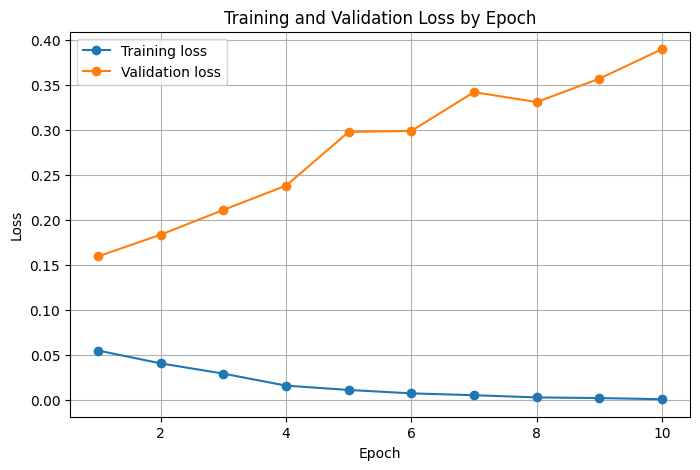

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert the Hugging Face Trainer history into a DataFrame.
# The Trainer automatically stores training loss and validation loss
# inside trainer.state.log_history while the model is training.
loss_history = pd.DataFrame(trainer.state.log_history)

# Keep only rows that contain training loss.
# These rows show the model's loss on the training data after each epoch.
train_loss = loss_history.dropna(subset=["loss"])[["epoch", "loss"]]

# Keep only rows that contain validation loss.
# These rows show the model's loss on unseen validation data after each epoch.
val_loss = loss_history.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]]

# Rename the columns to make the graph labels easier to understand.
train_loss = train_loss.rename(columns={"loss": "Training loss"})
val_loss = val_loss.rename(columns={"eval_loss": "Validation loss"})

# Create the loss graph.
# This is similar to the loss graph used in the NN-from-scratch notebook,
# but here the loss values come from the Hugging Face Trainer instead of a manual loop.
plt.figure(figsize=(8, 5))

# Plot training loss.
plt.plot(
    train_loss["epoch"],
    train_loss["Training loss"],
    marker="o",
    label="Training loss"
)

# Plot validation loss.
plt.plot(
    val_loss["epoch"],
    val_loss["Validation loss"],
    marker="o",
    label="Validation loss"
)

# Add labels and title so the graph is clear.
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss by Epoch")

# Show which line is training loss and which line is validation loss.
plt.legend()

# Add grid lines to make the graph easier to read.
plt.grid(True)

# Display the graph.
plt.show()

## Evaluate On Validation Data


In [32]:
# Evaluate the validation set with the default 0.5 threshold.
# This is useful as a first check, but because the dataset is imbalanced we also search
# for a better threshold in a later cell.
val_results = trainer.evaluate()

print(val_results)


Training Loss,Validation Loss,Epoch,Roc Auc,Accuracy,Precision,Recall,F1,Clean Correct,Clean Called Unclean,Unclean Called Clean,Unclean Correct
0.000831,0.159507,10,0.979844,0.966881,0.861295,0.803698,0.831500,28250,420,637,2608


{'eval_loss': 0.1595068871974945, 'eval_roc_auc': 0.9798436971800141, 'eval_accuracy': 0.9668807770640765, 'eval_precision': 0.8612945838837517, 'eval_recall': 0.8036979969183359, 'eval_f1': 0.8315000797066794, 'eval_clean_correct': 28250, 'eval_clean_called_unclean': 420, 'eval_unclean_called_clean': 637, 'eval_unclean_correct': 2608}


In [35]:
# Merge the test comments with their labels.
# test.csv has the text and test_labels.csv has the labels, so we join them by id.
# Rows with -1 labels are not real scored examples, so they are removed before testing.
test_full = test_df.merge(test_labels, on="id")
test_full = test_full[(test_full[target_cols] != -1).all(axis=1)].copy()

# Create the same binary label for test data that we created for training data.
# This keeps the target definition exactly the same: any original toxic label means unclean.
test_full["label_count"] = test_full[target_cols].sum(axis=1)
test_full["unclean"] = (test_full["label_count"] > 0).astype(int)
test_full["clean"] = 1 - test_full["unclean"]

test_full = test_full.reset_index(drop=True)

print("Usable test data:", test_full.shape)
print("Clean test comments:", test_full["clean"].sum())
print("Unclean test comments:", test_full["unclean"].sum())


Usable test data: (63978, 11)
Clean test comments: 57735
Unclean test comments: 6243


In [36]:
# Convert the prepared test table into a Hugging Face Dataset.
# Then apply the same tokenizer and label formatting used for training and validation.
test_dataset = Dataset.from_pandas(test_full)

test_dataset = test_dataset.map(
    preprocess_data,
    batched=True,
    remove_columns=test_dataset.column_names
)

test_dataset.set_format("torch")

print(test_dataset.column_names)


Map:   0%|          | 0/63978 [00:00<?, ? examples/s]

['input_ids', 'token_type_ids', 'attention_mask', 'labels']


## Evaluate On Test Data With Default Threshold


In [37]:
# Evaluate the test dataset with the default 0.5 threshold.
# This gives a direct comparison with the validation result above.
# The next section finds a threshold using validation data and then applies that threshold to test.
test_results = trainer.evaluate(
    eval_dataset=test_dataset
)

print(test_results)


Training Loss,Validation Loss,Epoch,Roc Auc,Accuracy,Precision,Recall,F1,Clean Correct,Clean Called Unclean,Unclean Called Clean,Unclean Correct
0.000831,0.393902,10,0.965844,0.914236,0.536607,0.887554,0.668839,52950,4785,702,5541


{'eval_loss': 0.39390185475349426, 'eval_roc_auc': 0.9658439255031365, 'eval_accuracy': 0.9142361436743881, 'eval_precision': 0.5366066240557815, 'eval_recall': 0.8875540605478136, 'eval_f1': 0.6688393988774217, 'eval_clean_correct': 52950, 'eval_clean_called_unclean': 4785, 'eval_unclean_called_clean': 702, 'eval_unclean_correct': 5541}


## Find Best Binary Threshold On Validation Data


In [38]:
# Get raw model predictions on the validation data.
# We use validation predictions to choose the threshold because the test set should be used
# only for the final score. This avoids tuning the threshold directly on test results.
val_output = trainer.predict(val_dataset)

val_logits = val_output.predictions.reshape(-1)
val_labels = val_output.label_ids.reshape(-1).astype(int)

# Convert logits to probabilities.
val_probs = 1 / (1 + np.exp(-val_logits))


In [1]:
# Search for the threshold that gives the best validation F1 score.
# Lower thresholds usually catch more unclean comments but can create more false positives.
# Higher thresholds usually reduce false positives but can miss more unclean comments.
# F1 is a good balance here because it considers both precision and recall.
best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.05, 0.96, 0.01):
    preds = (val_probs >= threshold).astype(int)
    f1 = f1_score(val_labels, preds, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", round(best_threshold, 2))
print("Best validation F1:", round(best_f1, 4))


NameError: name 'np' is not defined

In [2]:
# Get raw model predictions on the test data.
# We do not choose the threshold here. We only apply the threshold already chosen
# from the validation set above.
test_output = trainer.predict(test_dataset)

test_logits = test_output.predictions.reshape(-1)
test_labels_np = test_output.label_ids.reshape(-1).astype(int)

test_probs = 1 / (1 + np.exp(-test_logits))
test_preds = (test_probs >= best_threshold).astype(int)


NameError: name 'trainer' is not defined

In [3]:
# Calculate final binary test metrics using the validation-selected threshold.
# ROC-AUC uses probabilities because it checks ranking quality.
# Accuracy, precision, recall, and F1 use final clean/unclean predictions.
test_roc_auc = roc_auc_score(test_labels_np, test_probs)
test_accuracy = accuracy_score(test_labels_np, test_preds)
test_precision = precision_score(test_labels_np, test_preds, zero_division=0)
test_recall = recall_score(test_labels_np, test_preds, zero_division=0)
test_f1 = f1_score(test_labels_np, test_preds, zero_division=0)

print("Test ROC-AUC:", test_roc_auc)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)


NameError: name 'roc_auc_score' is not defined

In [42]:
# Build a confusion matrix so the mistakes are easy to understand.
# Rows show the real label. Columns show what the model predicted.
# The most important number to watch is Actual unclean / Predicted clean,
# because those are toxic comments the model missed.
cm = confusion_matrix(test_labels_np, test_preds, labels=[0, 1])

confusion_df = pd.DataFrame(
    cm,
    index=["Actual clean", "Actual unclean"],
    columns=["Predicted clean", "Predicted unclean"]
)

confusion_df


,Predicted clean,Predicted unclean
Actual clean,53592,4143
Actual unclean,829,5414


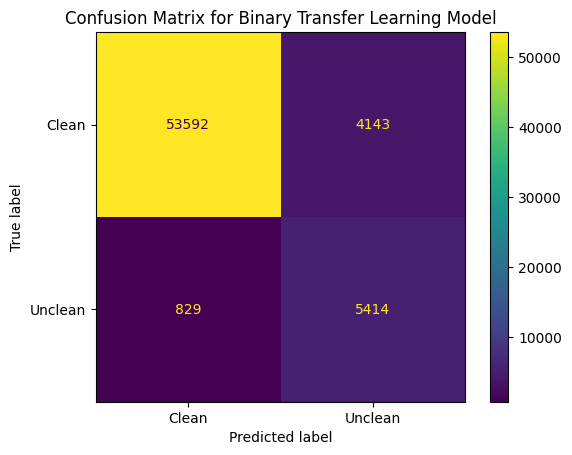

In [43]:
# Import matplotlib tools for drawing custom shapes and text.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Extract the four confusion matrix values.
# cm is assumed to be a 2x2 matrix in this order:
# [[true negatives, false positives],
#  [false negatives, true positives]]
tn = cm[0, 0]  # Actual clean predicted as clean
fp = cm[0, 1]  # Actual clean predicted as unclean
fn = cm[1, 0]  # Actual unclean predicted as clean
tp = cm[1, 1]  # Actual unclean predicted as unclean

# Create the figure.
fig, ax = plt.subplots(figsize=(12, 7))

# Set a light background color for the whole figure.
fig.patch.set_facecolor("#f2f2f2")
ax.set_facecolor("#f2f2f2")

# Remove axis lines and ticks.
ax.axis("off")

# Define box positions and size.
x0, y0 = 0.25, 0.35
box_w, box_h = 0.27, 0.18

# Define cell colors similar to your example.
correct_color = "#dfe8df"   # Greenish for correct predictions
error_top = "#f5ebbf"       # Yellow for false positives
error_bottom = "#f4dddd"    # Light red/pink for false negatives
edge_color = "#aab7c4"      # Border color
text_color = "#0b2a53"      # Dark blue text

# Draw the four confusion matrix boxes.
ax.add_patch(Rectangle((x0, y0 + box_h), box_w, box_h,
                       facecolor=correct_color, edgecolor=edge_color, linewidth=2.5))
ax.add_patch(Rectangle((x0 + box_w, y0 + box_h), box_w, box_h,
                       facecolor=error_top, edgecolor=edge_color, linewidth=2.5))
ax.add_patch(Rectangle((x0, y0), box_w, box_h,
                       facecolor=error_bottom, edgecolor=edge_color, linewidth=2.5))
ax.add_patch(Rectangle((x0 + box_w, y0), box_w, box_h,
                       facecolor=correct_color, edgecolor=edge_color, linewidth=2.5))

# Add the main title.
ax.text(0.5, 0.92, "Binary Transfer Learning Validation Confusion Matrix",
        ha="center", va="center", fontsize=30, fontweight="bold", color=text_color)

# Add column headings.
ax.text(x0 + box_w / 2, y0 + 2 * box_h + 0.05, "Predicted clean",
        ha="center", va="bottom", fontsize=22, fontweight="bold", color="#1f4f82")

ax.text(x0 + 1.5 * box_w, y0 + 2 * box_h + 0.05, "Predicted unclean",
        ha="center", va="bottom", fontsize=22, fontweight="bold", color="#1f4f82")

# Add row headings.
ax.text(x0 - 0.06, y0 + 1.5 * box_h, "Actual clean",
        ha="right", va="center", fontsize=22, fontweight="bold", color="#1f4f82")

ax.text(x0 - 0.06, y0 + 0.5 * box_h, "Actual unclean",
        ha="right", va="center", fontsize=22, fontweight="bold", color="#1f4f82")

# Add confusion matrix values.
ax.text(x0 + box_w / 2, y0 + 1.5 * box_h, f"{tn:,}",
        ha="center", va="center", fontsize=30, fontweight="bold", color=text_color)

ax.text(x0 + 1.5 * box_w, y0 + 1.5 * box_h, f"{fp:,}",
        ha="center", va="center", fontsize=30, fontweight="bold", color=text_color)

ax.text(x0 + box_w / 2, y0 + 0.5 * box_h, f"{fn:,}",
        ha="center", va="center", fontsize=30, fontweight="bold", color=text_color)

ax.text(x0 + 1.5 * box_w, y0 + 0.5 * box_h, f"{tp:,}",
        ha="center", va="center", fontsize=30, fontweight="bold", color=text_color)

# Add note at the bottom.
ax.text(0.5, 0.15,
        "Green cells are correct decisions. Yellow/red cells are review errors.",
        ha="center", va="center", fontsize=19, color="#555555")

# Display the figure.
plt.show()

In [44]:
# Store the final results in one small table for the report.
# This table is easier to copy into the write-up than separate print statements.
final_results = pd.DataFrame([
    {
        "threshold": best_threshold,
        "roc_auc": test_roc_auc,
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "clean_correct": cm[0, 0],
        "clean_called_unclean": cm[0, 1],
        "unclean_called_clean": cm[1, 0],
        "unclean_correct": cm[1, 1]
    }
])

final_results


,threshold,roc_auc,accuracy,precision,recall,f1,clean_correct,clean_called_unclean,unclean_called_clean,unclean_correct
0,0.92,0.965844,0.922286,0.566496,0.867211,0.685316,53592,4143,829,5414
